In [ ]:
import torch

from src.models.our_method.swin_cafm import SwinCAFM
from src.datasets.mos2_sr import (
    MOS2SRDataset,
    BTO_MANY_RES,
    MOS2_SEF_MANY_RES_SRC_DIR,
    MOS2_SAPPHIRE_DIR,
)
from src.datasets.mos2_sr import BTOSRDataset

In [38]:
weights_fp      = "__weights__/4x/DS={all}-[X|y]-BS=32-opt=Adam-lr=1e-5_best.pth"
dataset         = BTOSRDataset(upsample_factor=8)
model: SwinCAFM = torch.load(weights_fp).cuda()

/tmp/ipykernel_4028004/1787009233.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: SwinCAFM = torch.load(weights_fp).cuda()


In [ ]:
import numpy as np

sample_fp = "data/raw-data/5-15-25/Sample A2 scan 128 02-05-2025_250502_Z Height_Backward_003.npy"
X_sparse = torch.Tensor(np.load(sample_fp)).cuda().unsqueeze(0)

X_min = X_sparse.min()
X_max = X_sparse.max()
X_sparse = (X_sparse - X_sparse.min()) / (X_sparse.max() - X_sparse.min())

In [40]:
with torch.no_grad():
    X_hat: torch.Tensor = model(X_sparse)

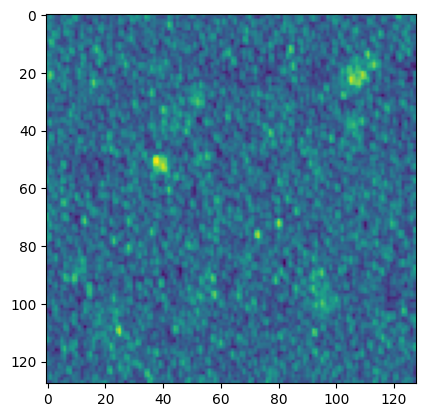

In [41]:
import matplotlib.pyplot as plt

X_hat = X_hat.cpu().squeeze()
X_sparse = X_sparse.cpu().squeeze().numpy()
plt.imshow(X_sparse);

# Plot
---

In [42]:
# TODO: unnormalize X_hat/X_sparse
X_max    = X_max.cpu(); X_min = X_min.cpu(); X_hat = X_hat.cpu(); X_sparse = torch.Tensor(X_sparse)
X_hat    = X_hat    * (X_max - X_min) + X_min
X_sparse = X_sparse * (X_max - X_min) + X_min

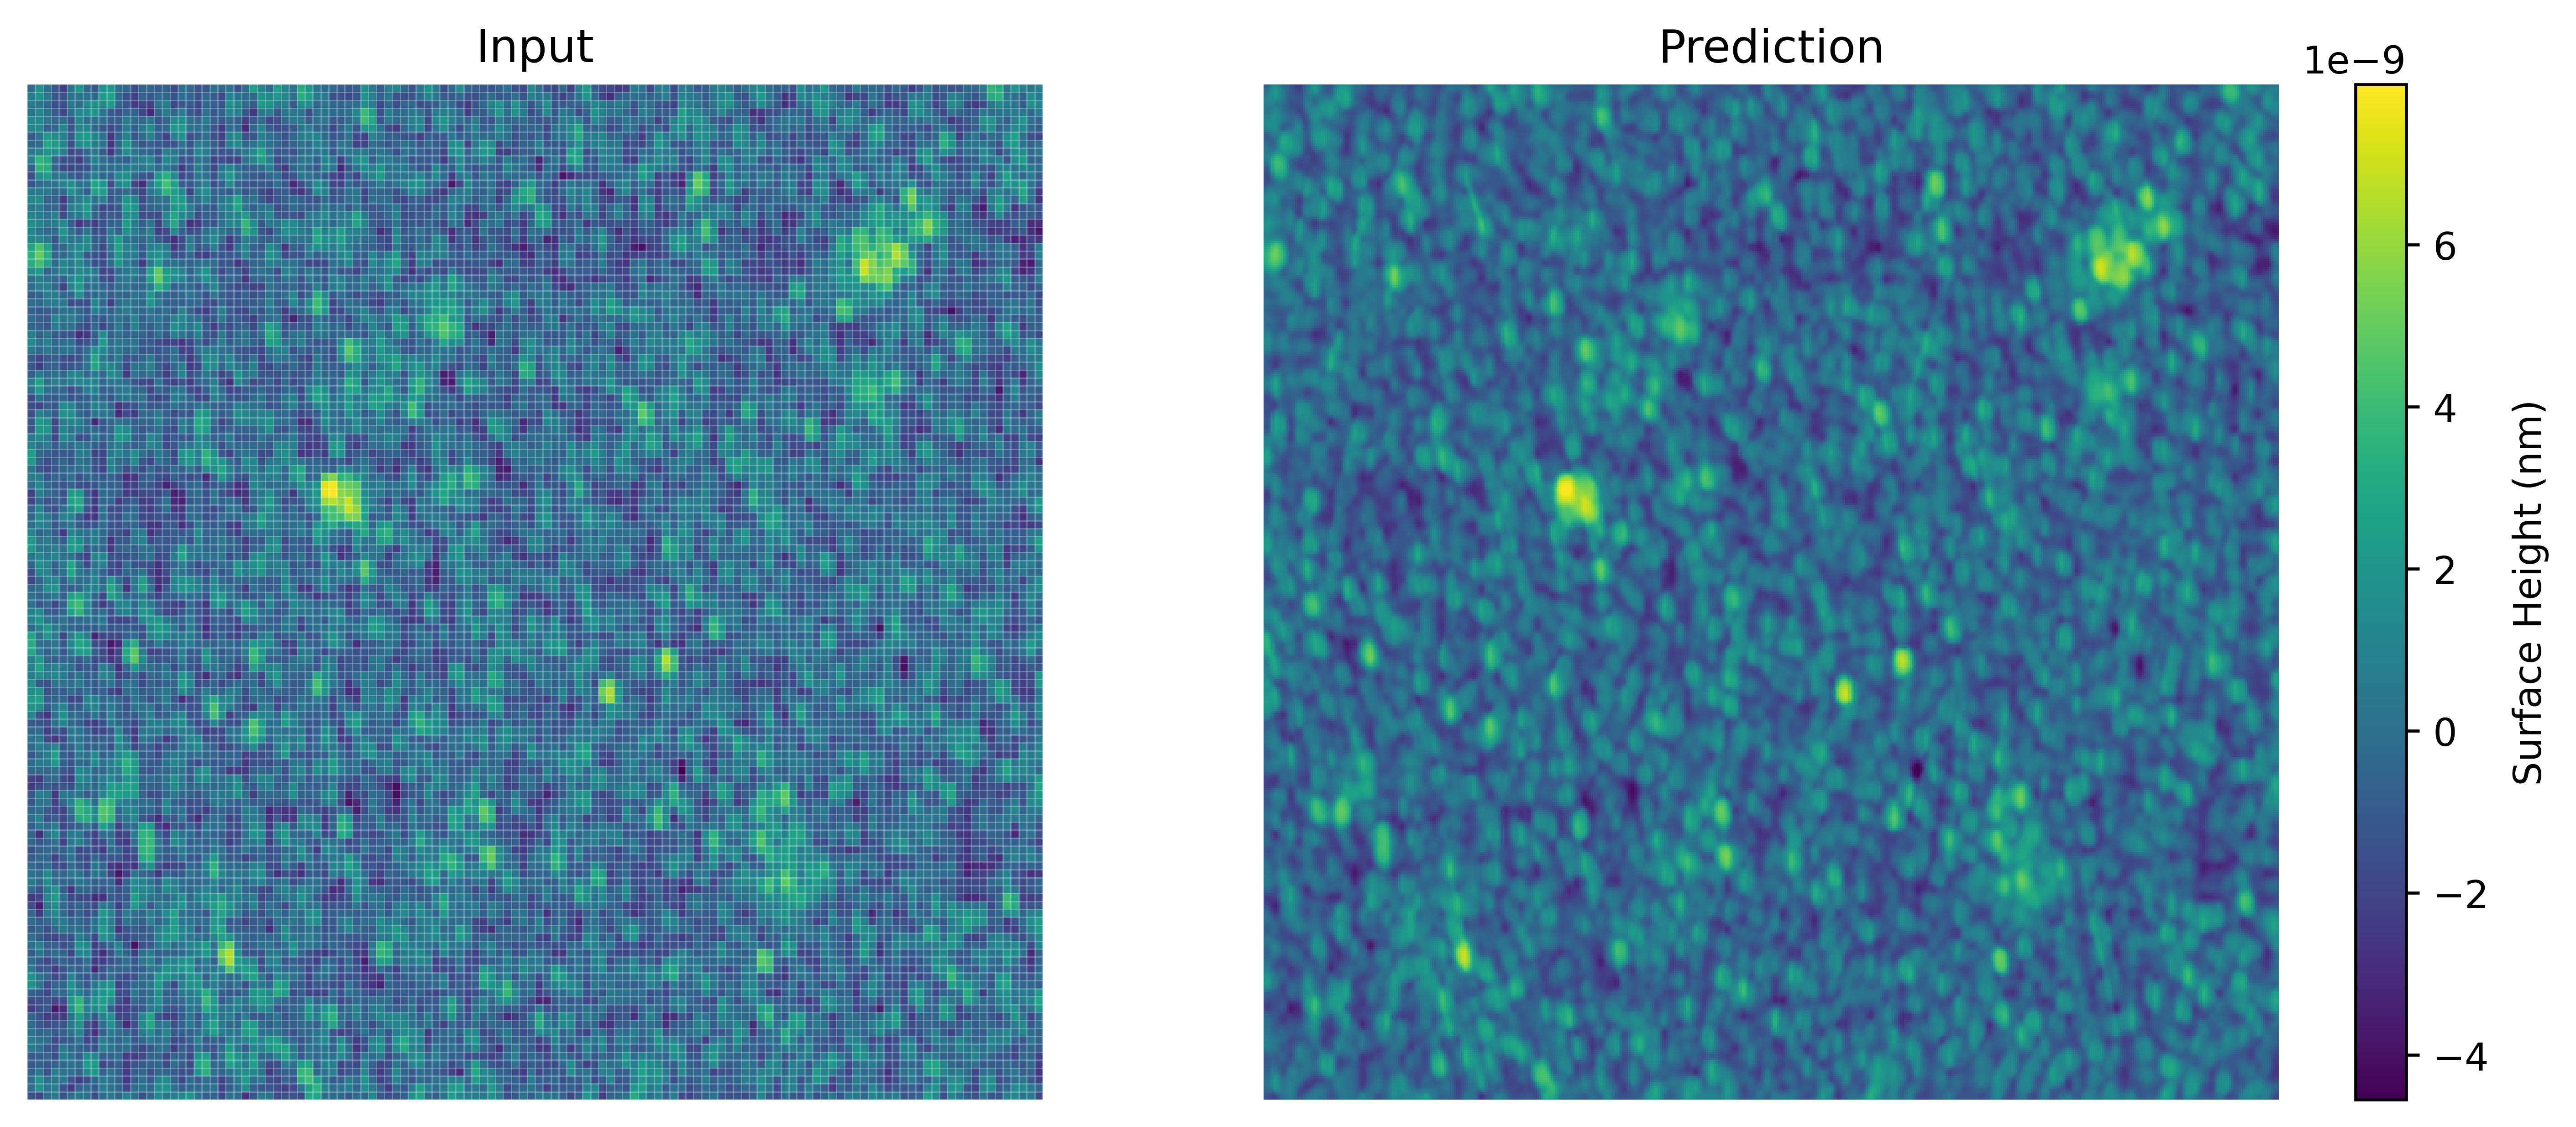

In [43]:
import numpy as np
import matplotlib.pyplot as plt


Xs = X_sparse
Xh = X_hat

# # HACK: set x_hat floor to 0
# if X_hat.min() < 0: X_hat -= X_hat.min()

Xs_masked = np.ma.masked_where(Xs == 0, Xs)
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, dpi=600)

im0 = ax[0].imshow(
    Xs_masked,
    cmap="viridis",
    interpolation="nearest",
)
ax[0].axis("off")

for i in range(Xs.shape[0] + 1):
    ax[0].axhline(i - 0.5, color="w", linewidth=0.3, alpha=0.3)
    ax[0].axvline(i - 0.5, color="w", linewidth=0.3, alpha=0.3)

im1 = ax[1].imshow(
    Xh,
    cmap="viridis",
)

ax[0].set_title("Input")
ax[1].set_title("Prediction")
ax[1].axis("off")

cbar = fig.colorbar(im1, ax=ax.ravel().tolist(), pad=0.01)
cbar.set_label("Surface Height (nm)", labelpad=6)

# plt.title("8x Upsampling – Test Sample")
plt.show()

In [47]:
from src.util.material_property_eval import calculate_roughness


X_hat_arr    = np.array(X_hat)
X_sparse_arr = np.array(X_sparse)
calculate_roughness(X_hat_arr), calculate_roughness(X_sparse_arr)

({'RMS roughness (Sq)': 1.3366896478572698,
  'Mean roughness (Sa)': 1.0396878913354612},
 {'RMS roughness (Sq)': 1.4359190503299146,
  'Mean roughness (Sa)': 1.1216145789916254})

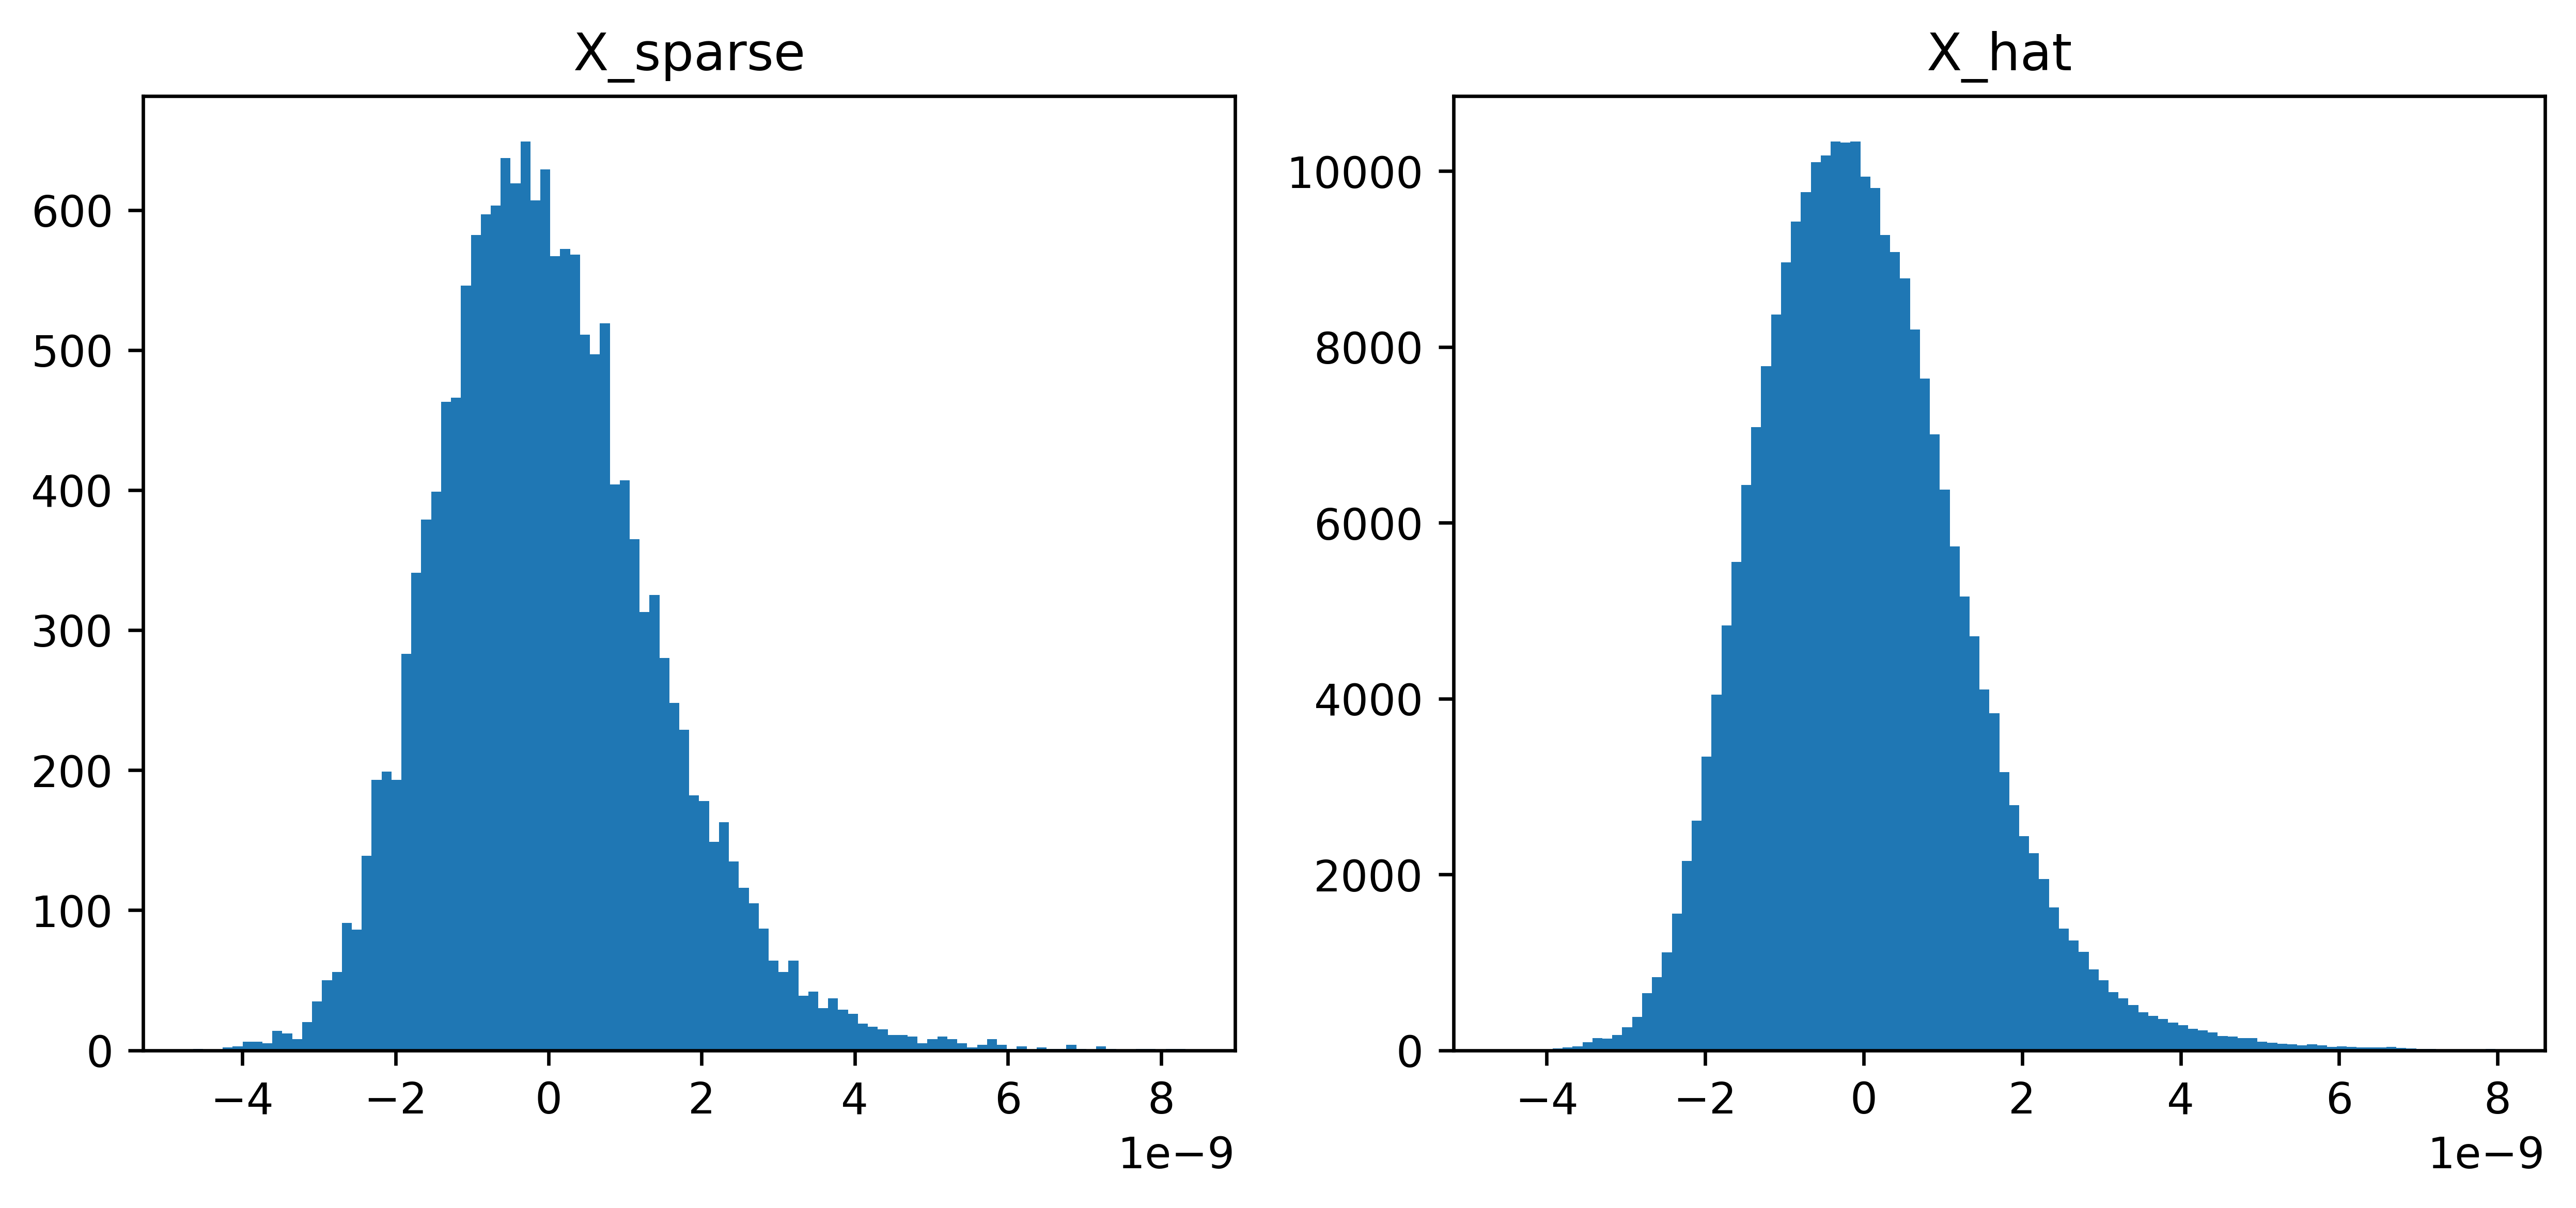

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=600)
ax[0].hist(X_sparse_arr.flatten(), bins=100)
ax[0].set_title("X_sparse")
ax[1].hist(X_hat_arr.flatten(), bins=100)
ax[1].set_title("X_hat")
plt.show();

In [60]:
import random
from tqdm import tqdm

NUM_BOOTSTRAPS = 100000

X_sparse_sr_vals = []
X_hat_sr_vals    = []


for _ in tqdm(range(NUM_BOOTSTRAPS)):

    # grab a (64, 64) crop
    h = random.randint(0, 64)
    w = random.randint(0, 64)

    # X_sparse
    crop = X_sparse[h: h + 64, w: w + 64]
    sr_XS = calculate_roughness(crop)['RMS roughness (Sq)']
    X_sparse_sr_vals.append(sr_XS)
    
    # X_hat
    crop = X_hat[h: h + 64, w: w + 64]
    sr_XH = calculate_roughness(crop)['RMS roughness (Sq)']
    X_hat_sr_vals.append(sr_XH)

100%|██████████| 100000/100000 [00:10<00:00, 9603.84it/s]


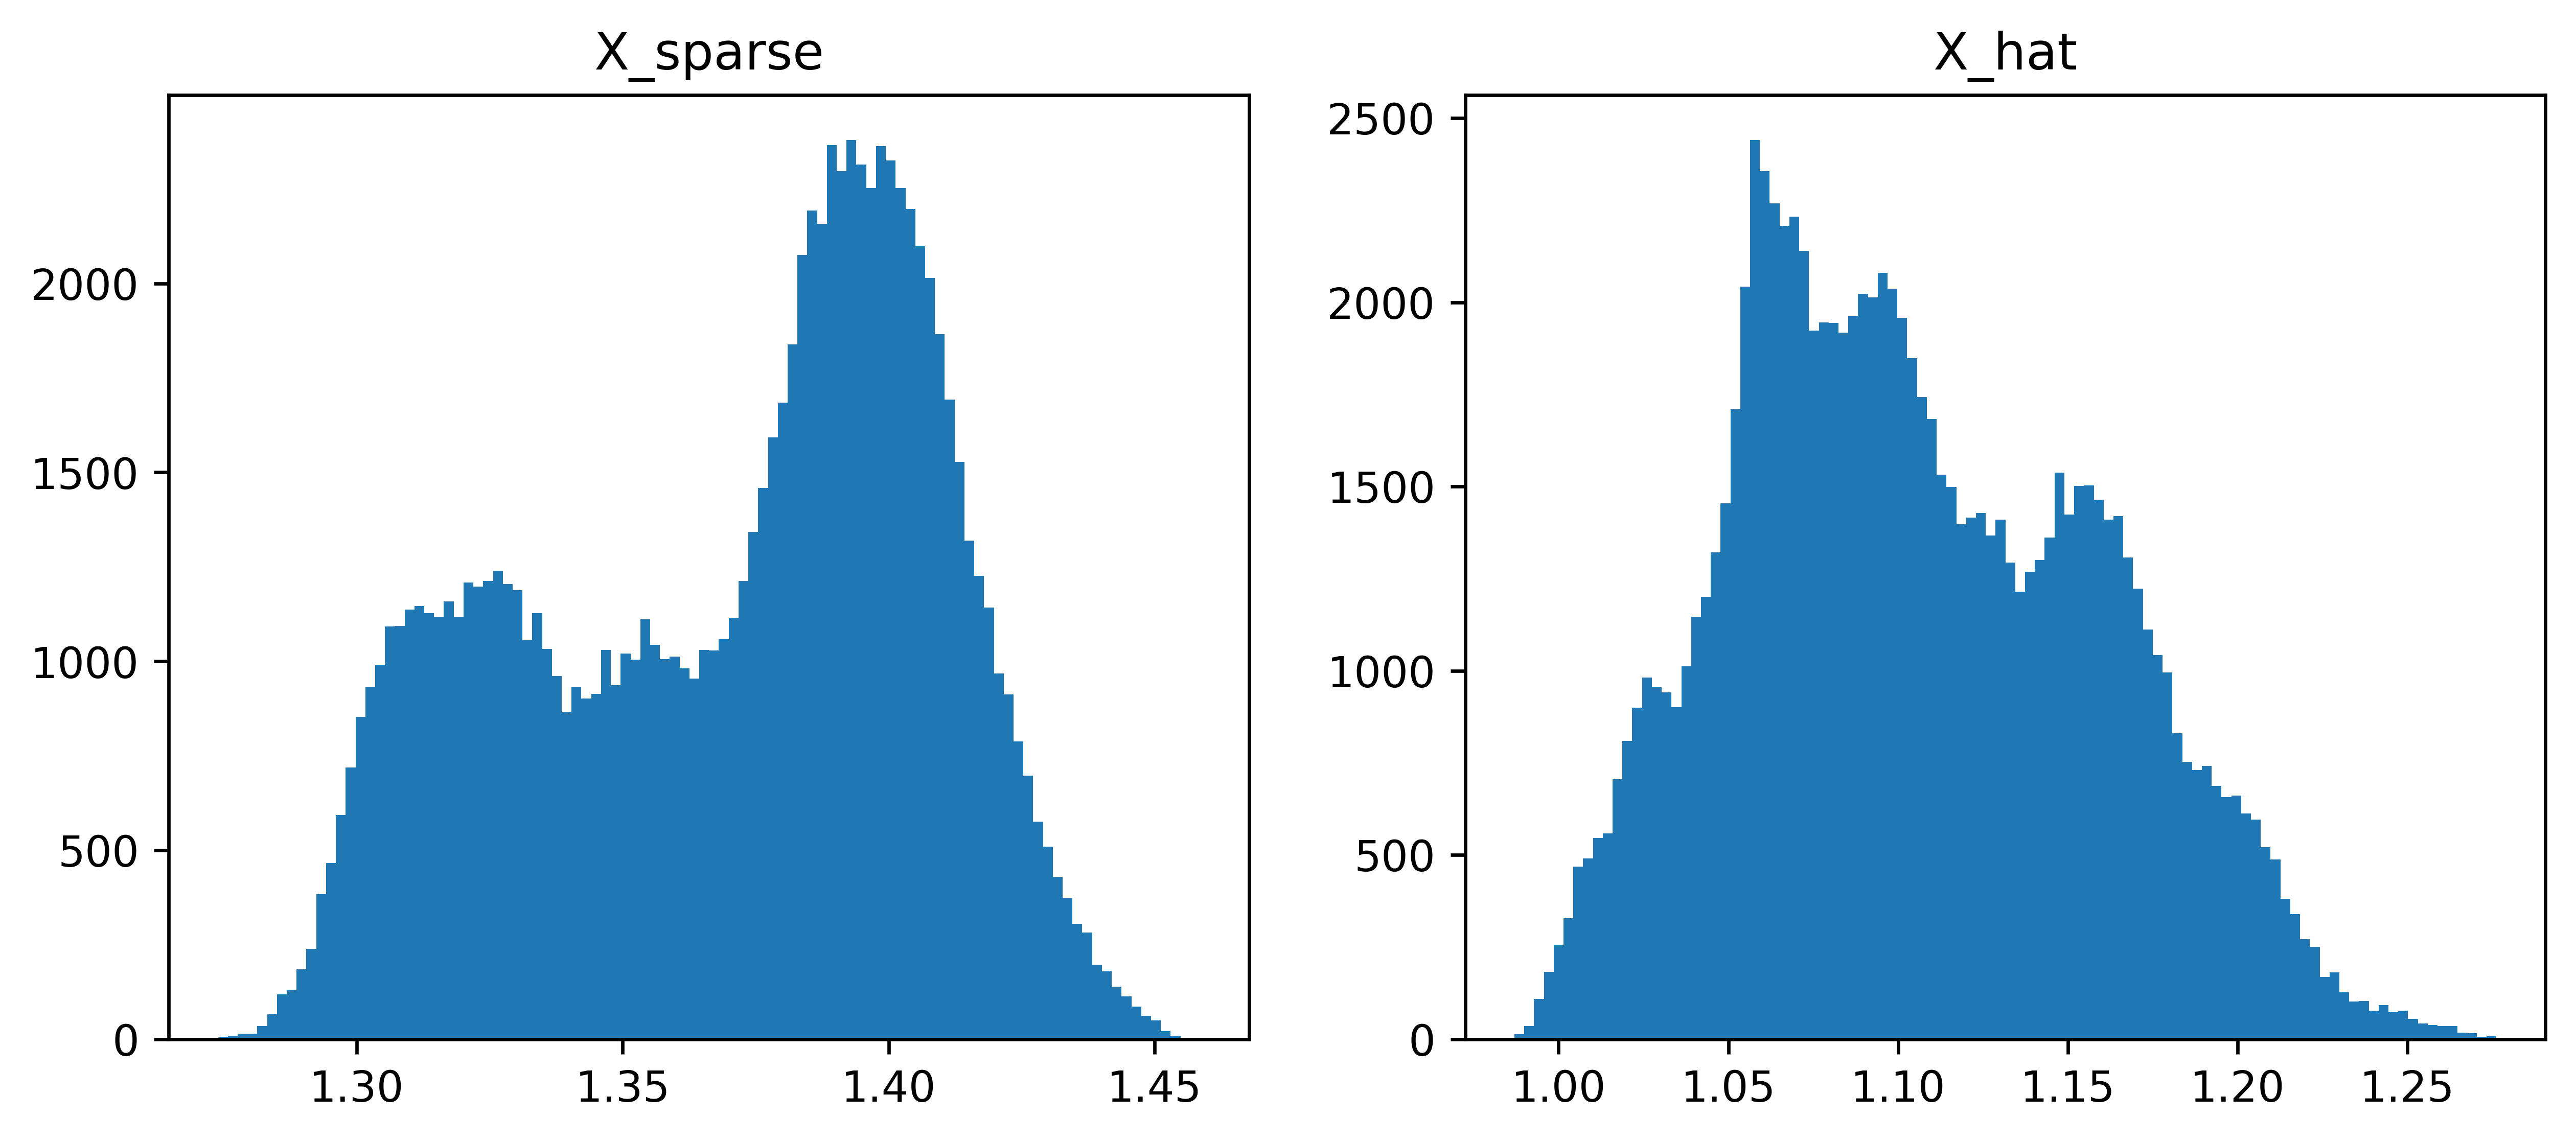

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=600)
ax[0].hist(X_sparse_sr_vals, bins=100)
ax[0].set_title("X_sparse")
ax[1].hist(X_hat_sr_vals, bins=100)
ax[1].set_title("X_hat")
plt.show();